
# 🌳 FINAL PREMIUM NOTEBOOK – Decision Trees (Deep Theory + Intuition)

This notebook is designed for **serious ML understanding (interview + real-world level)**.

What makes this premium:
- Deep paragraph-style teaching (not bullets)
- Strong intuition + math connection
- BFSI real-world mapping (fraud, credit risk)
- Visual thinking (how model actually splits)
- Hands-on + explanation

---



## 🔰 Decision Trees – Beginner Intuition (10 Lines)

A Decision Tree works like human decision-making. It asks a series of questions. Each question splits data into smaller groups. The goal is to make groups as pure as possible. It can solve classification and regression problems. It does not assume linear relationships. It is easy to explain to business users. However, it can overfit easily. Proper tuning is required. It is the foundation of ensemble models.

---


# 🌱 Decision Tree Basics (Deep Intuition)
---

## 🧠 Explanation
A Decision Tree is a recursive partitioning algorithm. Instead of fitting a global equation like linear regression,
it breaks the dataset into smaller regions. At each step, it chooses a feature and a split point such that the resulting
groups become more homogeneous.

Think of it as dividing a messy room into smaller sections until each section contains only similar items. This is why
decision trees are extremely powerful for non-linear problems. The tree structure is composed of root, internal nodes,
and leaf nodes. Each path from root to leaf represents a decision rule.

## 📐 Formula & Intuition
No single formula. It is based on recursive binary splitting.

## 🏦 Real-Life Use Case (BFSI Focus)
In credit risk modeling, a bank may segment customers:
If income > threshold → Check repayment history → Approve or reject loan.

This makes the model interpretable to regulators.

## ⚠️ Limitation
Trees are greedy. They choose the best split at each step, not globally optimal splits.

## 🔄 Comparison / Types
Compared to Logistic Regression, trees capture non-linearity without feature transformation.

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
model = DecisionTreeClassifier(max_depth=3)
print(X[0])
model.fit(X, y)
Z = [3.1, 2.5, 6.4, 12.7]
print(model.predict([Z]))

[5.1 3.5 1.4 0.2]
[2]


---

# 🌿 Classification vs Regression Trees (Deep Understanding)
---

## 🧠 Explanation
The same tree structure behaves differently depending on the problem.

In classification, the goal is to create nodes where one class dominates. The prediction is based on majority voting.
In regression, the goal is to minimize variance within nodes, and predictions are averages.

This difference fundamentally changes how splits are evaluated and how predictions are computed.

## 📐 Formula & Intuition
Classification → Majority Class  
Regression → Mean Value

## 🏦 Real-Life Use Case (BFSI Focus)
Fraud detection → Classification (fraud / not fraud)

Loan amount prediction → Regression (continuous value)

## ⚠️ Limitation
Regression trees can produce piecewise constant outputs, which may look unnatural for smooth problems.

## 🔄 Comparison / Types
Classification Trees vs Regression Trees vs Linear Models

In [19]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

X = np.array([[1],[2],[3],[4]])
y = np.array([10,20,30,40])

model = DecisionTreeRegressor(max_depth=2)
model.fit(X,y)
print(model.predict([[2.5]]))

[20.]


---

# ⚠️ Overfitting + Pruning (Critical Concept)
---

## 🧠 Explanation
Decision Trees have extremely high variance. If allowed to grow fully, they memorize training data.

This leads to overfitting, where the model performs well on training data but poorly on unseen data.

Pruning solves this by reducing tree complexity. Pre-pruning stops tree growth early using constraints like max_depth.
Post-pruning removes branches after full growth based on cost-complexity tradeoff.

## 📐 Formula & Intuition
Cost Complexity = Error + α × Number of Leaves

## 🏦 Real-Life Use Case (BFSI Focus)
In fraud detection, memorizing past fraud patterns is dangerous because new fraud patterns keep evolving.
Pruning helps generalization.

## ⚠️ Limitation
Too aggressive pruning leads to underfitting.

## 🔄 Comparison / Types
Pre-pruning vs Post-pruning vs Regularization in Linear Models

In [20]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5)
model.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


---

# 📊 Entropy (Deep Mathematical Intuition)
---

## 🧠 Explanation
Entropy comes from information theory. It measures uncertainty in a dataset.

If a node contains a perfect mix of classes, uncertainty is maximum. If it contains only one class, uncertainty is zero.
The decision tree tries to reduce entropy at every split.

You can think of entropy as 'impurity' or 'disorder'. The model prefers splits that reduce disorder the most.

## 📐 Formula & Intuition
Entropy = - Σ p log₂(p)

If p = 0 or 1 → Entropy = 0 (pure node)

## 🏦 Real-Life Use Case (BFSI Focus)
In churn prediction, if customers are evenly split between churn and not churn,
uncertainty is high → entropy is high → model wants to split.

## ⚠️ Limitation
Logarithmic computation is slightly expensive.

## 🔄 Comparison / Types
Entropy vs Gini vs Variance Reduction

In [26]:
import numpy as np

p = [0.5, 0.5]
entropy = -sum([i*np.log2(i) for i in p])
print(entropy)

1.0


---

# 📊 Gini Index (Practical Industry Metric)
---

## 🧠 Explanation
Gini Index is another impurity measure but computationally simpler than entropy.

It represents the probability of misclassification. Lower Gini means higher purity.

Most libraries like sklearn use Gini by default because it is faster and performs similarly.

## 📐 Formula & Intuition
Gini = 1 - Σ(p²)

## 🏦 Real-Life Use Case (BFSI Focus)
Used in real-time fraud systems where computation speed matters.

## ⚠️ Limitation
Less sensitive than entropy in some edge cases.

## 🔄 Comparison / Types
Gini vs Entropy (speed vs interpretability)

In [25]:
p = [0.5, 0.5]
gini = 1 - sum([i**2 for i in p])
print(gini)

0.5


---

# 📈 Information Gain (How Tree Chooses Split)
---

## 🧠 Explanation
Information Gain measures how much uncertainty is reduced after a split.

The model calculates entropy before the split and after the split. The difference is the gain.

The feature and split point that gives the highest gain is selected. This is the core decision-making mechanism of trees.

## 📐 Formula & Intuition
IG = Entropy(parent) - Weighted Entropy(children)

## 🏦 Real-Life Use Case (BFSI Focus)
In loan approval, the model selects features like income or credit score based on highest information gain.

## ⚠️ Limitation
Biased towards features with many categories (e.g., ID columns).

## 🔄 Comparison / Types
Information Gain vs Gini Reduction

In [ ]:
# Conceptual demonstration
# Actual implementation handled internally by sklearn

---

# ⚖️ Gini vs Entropy (Interview-Level Understanding)
---

## 🧠 Explanation
Both Gini and Entropy measure impurity, but they differ slightly in behavior.

Gini is computationally faster and tends to isolate the most frequent class.
Entropy is more theoretically grounded in information theory and can be slightly more sensitive.

In practice, both give similar results, which is why Gini is preferred in production systems.

## 📐 Formula & Intuition
Refer to formulas above

## 🏦 Real-Life Use Case (BFSI Focus)
Banks typically use Gini for faster training in large datasets.

## ⚠️ Limitation
Differences are often negligible.

## 🔄 Comparison / Types
Gini vs Entropy vs Misclassification Error

# Example - Decision Tree on Classification

In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [28]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=20000,          # bigger dataset
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    weights=[0.95, 0.05],    # imbalanced (fraud ~5%)
    random_state=42
)

df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(10)])
df['fraud'] = y

df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,fraud
0,0.320369,-0.520241,0.226862,-1.934781,-1.947447,-2.051393,0.262367,-0.900924,-1.498455,-2.294892,0
1,0.171203,-1.328328,-0.464534,-0.586279,-1.261397,-3.252064,1.153607,-2.241961,0.616120,-1.538542,0
2,-1.503444,2.957689,-1.134412,1.351797,0.388065,1.924340,-1.260189,-0.472208,0.039989,-1.761144,0
3,-1.680857,1.315571,-1.084441,0.927292,-1.636048,-0.697179,-1.859559,-0.984415,1.393748,0.368163,0
4,0.258858,1.332051,-0.365772,-2.923181,-2.768885,-0.353311,0.375830,0.366101,1.682550,-3.280432,0


In [29]:
X = df.drop('fraud', axis=1)
y = df['fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [30]:
dt_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

dt_gini.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [31]:
dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

dt_entropy.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
y_pred_gini = dt_gini.predict(X_test)
y_pred_entropy = dt_entropy.predict(X_test)

In [33]:
print("Gini Model")
print(confusion_matrix(y_test, y_pred_gini))
print(classification_report(y_test, y_pred_gini))
print("ROC AUC:", roc_auc_score(y_test, dt_gini.predict_proba(X_test)[:,1]))

print("\nEntropy Model")
print(confusion_matrix(y_test, y_pred_entropy))
print(classification_report(y_test, y_pred_entropy))
print("ROC AUC:", roc_auc_score(y_test, dt_entropy.predict_proba(X_test)[:,1]))

Gini Model
[[3755   26]
 [ 122   97]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3781
           1       0.79      0.44      0.57       219

    accuracy                           0.96      4000
   macro avg       0.88      0.72      0.77      4000
weighted avg       0.96      0.96      0.96      4000

ROC AUC: 0.8806070728552642

Entropy Model
[[3768   13]
 [ 138   81]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3781
           1       0.86      0.37      0.52       219

    accuracy                           0.96      4000
   macro avg       0.91      0.68      0.75      4000
weighted avg       0.96      0.96      0.96      4000

ROC AUC: 0.9031917578761386


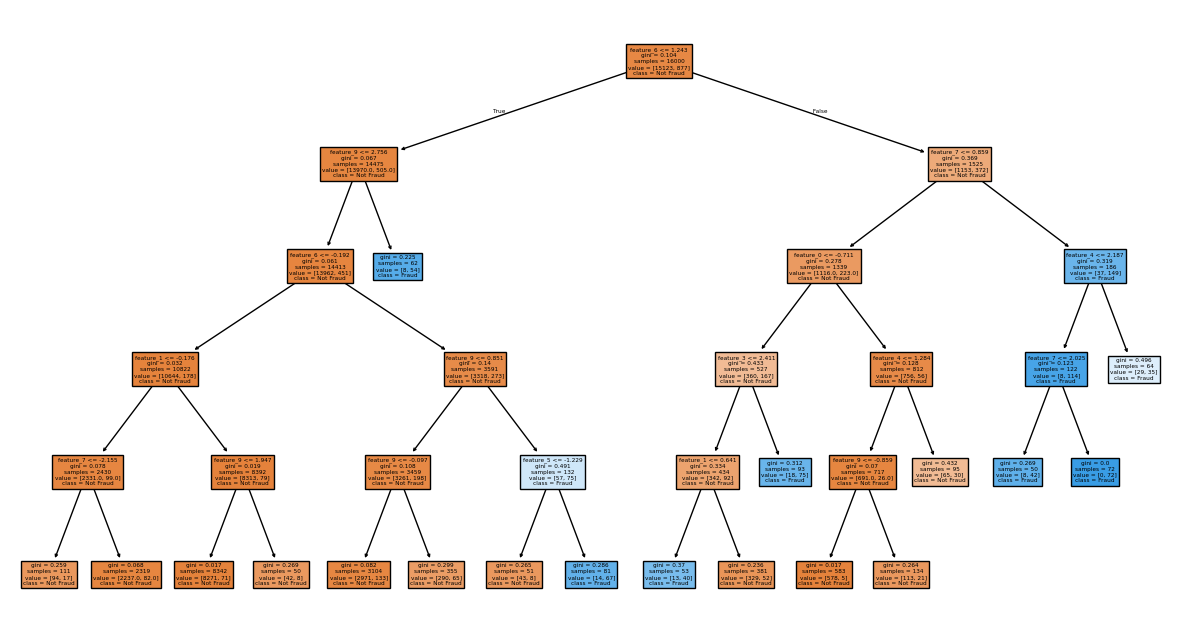

In [34]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))
plot_tree(dt_gini, filled=True, feature_names=X.columns, class_names=["Not Fraud", "Fraud"])
plt.show()